# DPL Tag Classifier — CPU Models with Confidence Scores

All three models now return **calibrated probability scores** for every prediction.

| Model | How confidence is produced |
|---|---|
| TF-IDF + Calibrated SVC | `CalibratedClassifierCV` wraps LinearSVC with sigmoid calibration |
| TF-IDF + Logistic Regression | Native `predict_proba()` |
| DistilBERT | Softmax over logits |

**Confidence score** = probability the model assigns to its top prediction (0 → 1).  
A score of **0.90** means the model is 90% sure it picked the right tag.

## Structure
1. Load dataset & label encoding  
2. Model A — Calibrated SVC (with confidence)  
3. Model B — Logistic Regression (with confidence)  
4. Model C — DistilBERT (with confidence)  
5. Calibration quality — reliability diagrams  
6. Confidence threshold analysis  
7. Save models  
8. Inference helper — top-K with confidence  

## 1. Load Dataset & Label Encoding

In [1]:
import pandas as pd
import numpy as np
import json, os, time, warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

DATASETS_DIR = "datasets"
train_df    = pd.read_csv(f"{DATASETS_DIR}/dpl_train.csv")
val_df      = pd.read_csv(f"{DATASETS_DIR}/dpl_val.csv")
test_df     = pd.read_csv(f"{DATASETS_DIR}/dpl_test.csv")
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

le = LabelEncoder()
le.fit(sorted(train_df["dpl_tag"].unique()))
NUM_LABELS = len(le.classes_)

X_tv   = trainval_df["description"].tolist()
y_tv   = le.transform(trainval_df["dpl_tag"])
X_test = test_df["description"].tolist()
y_test = le.transform(test_df["dpl_tag"])

print(f"Train+Val : {len(trainval_df):,}  |  Test: {len(test_df):,}  |  Classes: {NUM_LABELS}")

Train+Val : 12,851  |  Test: 2,272  |  Classes: 76


## 2. Model A — TF-IDF + Calibrated SVC

`LinearSVC` has no built-in probability output. `CalibratedClassifierCV` fits a sigmoid (Platt scaling) on top to produce calibrated probabilities. This adds ~30 seconds to training.

In [2]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def tfidf_features():
    return FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word", ngram_range=(1, 3),
            min_df=2, max_features=100_000, sublinear_tf=True,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3, 5),
            min_df=3, max_features=50_000, sublinear_tf=True,
        )),
    ])


# CalibratedClassifierCV uses cross-validation internally to fit the sigmoid
# cv=3 keeps it fast; use cv=5 for better calibration if time allows
svc_pipeline = Pipeline([
    ("features", tfidf_features()),
    ("clf", CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, dual="auto"),
        method="sigmoid",
        cv=3,
    )),
])

t0 = time.time()
svc_pipeline.fit(X_tv, y_tv)
svc_time = time.time() - t0

svc_preds = svc_pipeline.predict(X_test)
svc_probs = svc_pipeline.predict_proba(X_test)      # shape (n_test, 76)
svc_conf  = svc_probs.max(axis=1)                   # top-1 confidence per sample

svc_acc = accuracy_score(y_test, svc_preds)
svc_f1  = f1_score(y_test, svc_preds, average="weighted", zero_division=0)

print(f"Training time     : {svc_time:.1f}s")
print(f"Accuracy          : {svc_acc:.4f}")
print(f"Weighted F1       : {svc_f1:.4f}")
print(f"Mean confidence   : {svc_conf.mean():.4f}")
print(f"Median confidence : {np.median(svc_conf):.4f}")
print(f"Low-conf (<0.5)   : {(svc_conf < 0.5).sum()} samples ({100*(svc_conf<0.5).mean():.1f}%)")

Training time     : 8.0s
Accuracy          : 0.9996
Weighted F1       : 0.9996
Mean confidence   : 0.9777
Median confidence : 0.9797
Low-conf (<0.5)   : 0 samples (0.0%)


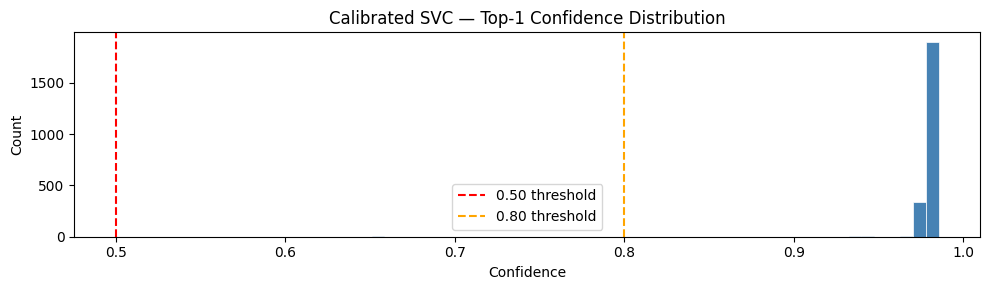

In [3]:
# Confidence distribution
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(svc_conf, bins=50, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(0.5,  color="red",    linestyle="--", label="0.50 threshold")
ax.axvline(0.80, color="orange", linestyle="--", label="0.80 threshold")
ax.set_title("Calibrated SVC — Top-1 Confidence Distribution")
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Model B — TF-IDF + Logistic Regression

In [4]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("features", tfidf_features()),
    ("clf", LogisticRegression(C=5.0, max_iter=1000, solver="saga", n_jobs=-1)),
])

t0 = time.time()
lr_pipeline.fit(X_tv, y_tv)
lr_time = time.time() - t0

lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)
lr_conf  = lr_probs.max(axis=1)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average="weighted", zero_division=0)

print(f"Training time     : {lr_time:.1f}s")
print(f"Accuracy          : {lr_acc:.4f}")
print(f"Weighted F1       : {lr_f1:.4f}")
print(f"Mean confidence   : {lr_conf.mean():.4f}")
print(f"Median confidence : {np.median(lr_conf):.4f}")
print(f"Low-conf (<0.5)   : {(lr_conf < 0.5).sum()} samples ({100*(lr_conf<0.5).mean():.1f}%)")

Training time     : 17.1s
Accuracy          : 0.9996
Weighted F1       : 0.9996
Mean confidence   : 0.9599
Median confidence : 0.9727
Low-conf (<0.5)   : 1 samples (0.0%)


## 4. Model C — DistilBERT

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset, DatasetDict

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = "distilbert-base-uncased"
MAX_LENGTH  = 64

id2label = {int(i): str(c) for i, c in enumerate(le.classes_)}
label2id = {str(c): int(i) for i, c in enumerate(le.classes_)}

tokenizer_db = AutoTokenizer.from_pretrained(CHECKPOINT)

def df_to_hf(df):
    return Dataset.from_dict({
        "text":  df["description"].tolist(),
        "label": le.transform(df["dpl_tag"]).tolist(),
    })

def tokenize(batch):
    return tokenizer_db(batch["text"], truncation=True,
                        padding="max_length", max_length=MAX_LENGTH)

tok_ds = DatasetDict({
    "train": df_to_hf(trainval_df),
    "test":  df_to_hf(test_df),
}).map(tokenize, batched=True, remove_columns=["text"])
tok_ds.set_format("torch")

model_db = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT, num_labels=NUM_LABELS,
    id2label=id2label, label2id=label2id,
).to(DEVICE)
print(f"Model: {sum(p.numel() for p in model_db.parameters()):,} parameters")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/12851 [00:00<?, ? examples/s]

Map:   0%|          | 0/2272 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: 67,011,916 parameters


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }

EPOCHS, BATCH = 5, 64
total_steps  = max(1, len(tok_ds["train"]) // BATCH) * EPOCHS
warmup_steps = int(total_steps * 0.1)

db_args = TrainingArguments(
    output_dir                  = "models/distilbert_conf/checkpoints",
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH,
    per_device_eval_batch_size  = 128,
    learning_rate               = 3e-5,
    weight_decay                = 0.01,
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = "cosine",
    bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16 = torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    greater_is_better           = True,
    logging_steps               = 50,
    report_to                   = "none",
    save_total_limit            = 1,
    seed                        = 42,
    use_cpu                     = (DEVICE == "cpu"),
    dataloader_num_workers      = 0,   # set to 4 on Linux
)

db_trainer = Trainer(
    model            = model_db,
    args             = db_args,
    train_dataset    = tok_ds["train"],
    eval_dataset     = tok_ds["test"],
    processing_class = tokenizer_db,
    compute_metrics  = compute_metrics,
)
print(f"Total steps: {total_steps}  |  Warmup: {warmup_steps}")

Total steps: 1000  |  Warmup: 100


In [7]:
t0 = time.time()
db_trainer.train()
print(f"DistilBERT training: {(time.time()-t0)/60:.1f} min")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,7.794323,6.493886,0.866197,0.857071
2,3.321229,1.947632,0.976232,0.972484
3,0.967947,0.498044,0.997359,0.997358
4,0.414122,0.241137,0.998680,0.998678
5,0.328259,0.213958,0.999120,0.999119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT training: 3.0 min


In [8]:
# Extract softmax probabilities from DistilBERT
db_output = db_trainer.predict(tok_ds["test"])
db_logits = torch.tensor(db_output.predictions)
db_probs  = torch.softmax(db_logits, dim=-1).numpy()  # shape (n_test, 76)
db_preds  = db_probs.argmax(axis=1)
db_conf   = db_probs.max(axis=1)

db_acc = accuracy_score(y_test, db_preds)
db_f1  = f1_score(y_test, db_preds, average="weighted", zero_division=0)

print(f"Accuracy          : {db_acc:.4f}")
print(f"Weighted F1       : {db_f1:.4f}")
print(f"Mean confidence   : {db_conf.mean():.4f}")
print(f"Median confidence : {np.median(db_conf):.4f}")
print(f"Low-conf (<0.5)   : {(db_conf < 0.5).sum()} samples ({100*(db_conf<0.5).mean():.1f}%)")

Accuracy          : 0.9991
Weighted F1       : 0.9991
Mean confidence   : 0.9010
Median confidence : 0.9074
Low-conf (<0.5)   : 5 samples (0.2%)


## 5. Calibration Quality — Reliability Diagrams

A well-calibrated model predicts confidence 0.8 and is actually correct 80% of the time.  
Points above the diagonal = **underconfident**. Below = **overconfident**.

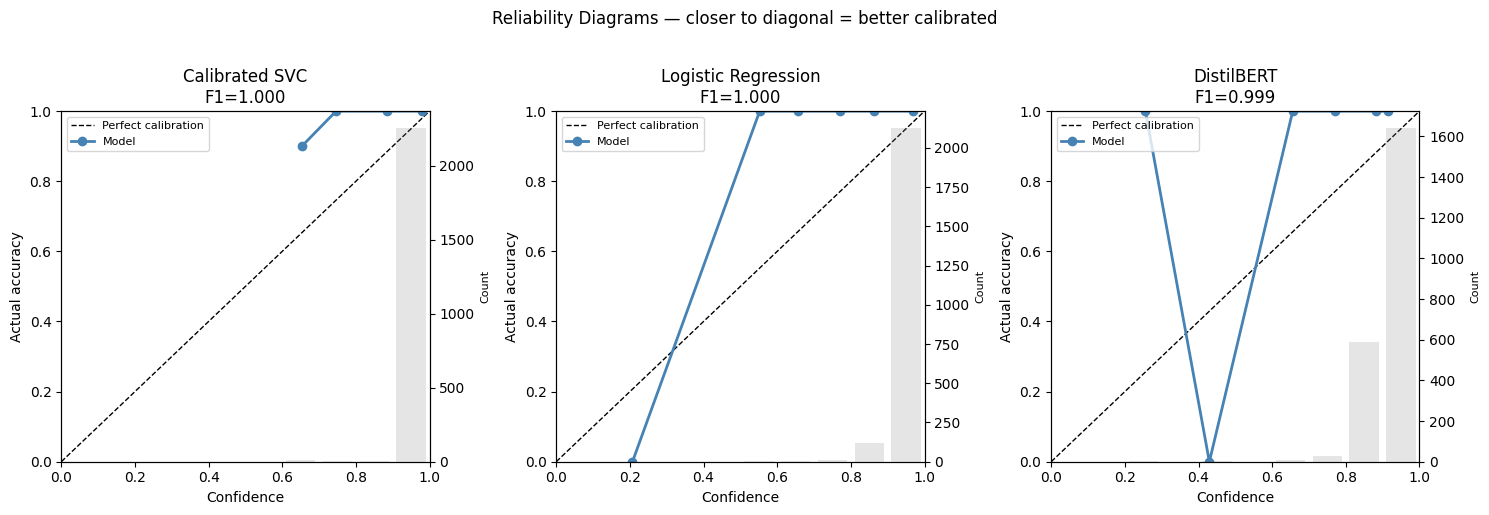

In [9]:
from sklearn.calibration import calibration_curve

# Binary correct/incorrect for calibration curve
models_conf = {
    "Calibrated SVC": (svc_preds, svc_probs, svc_conf),
    "Logistic Regression": (lr_preds, lr_probs, lr_conf),
    "DistilBERT": (db_preds, db_probs, db_conf),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, (preds, probs, conf)) in zip(axes, models_conf.items()):
    correct  = (preds == y_test).astype(int)
    n_bins   = 10
    bins     = np.linspace(0, 1, n_bins + 1)
    bin_acc, bin_conf_mean, bin_counts = [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() > 0:
            bin_acc.append(correct[mask].mean())
            bin_conf_mean.append(conf[mask].mean())
            bin_counts.append(mask.sum())

    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.plot(bin_conf_mean, bin_acc, "o-", color="steelblue", linewidth=2, label="Model")
    ax2 = ax.twinx()
    ax2.bar(
        [(lo + hi) / 2 for lo, hi in zip(bins[:-1], bins[1:])],
        [mask.sum() for lo, hi in zip(bins[:-1], bins[1:])
         for mask in [(conf >= lo) & (conf < hi)]],
        width=0.08, alpha=0.2, color="grey", label="Sample count"
    )
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence"); ax.set_ylabel("Actual accuracy")
    ax.set_title(f"{name}\nF1={f1_score(y_test, preds, average='weighted', zero_division=0):.3f}")
    ax.legend(loc="upper left", fontsize=8)
    ax2.set_ylabel("Count", fontsize=8)

plt.suptitle("Reliability Diagrams — closer to diagonal = better calibrated", y=1.02)
plt.tight_layout()
plt.show()

## 6. Confidence Threshold Analysis

By only accepting predictions above a confidence threshold, accuracy on the **accepted** predictions improves — at the cost of more **abstentions** (deferred to human review).

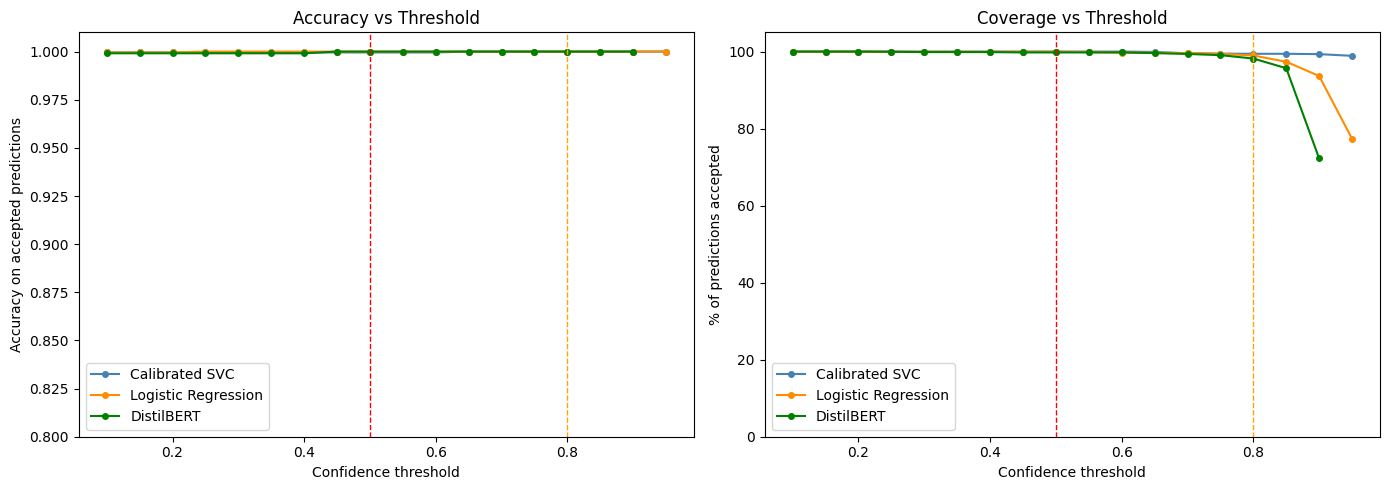


Model                    Thr   Coverage    Acc@Thr
----------------------------------------------------
Calibrated SVC          0.50     100.0%     0.9996
Calibrated SVC          0.80      99.4%     1.0000
LogReg                  0.50     100.0%     1.0000
LogReg                  0.80      99.0%     1.0000
DistilBERT              0.50      99.8%     1.0000
DistilBERT              0.80      98.2%     1.0000


In [10]:
def threshold_analysis(preds, conf, y_true, label):
    thresholds = np.arange(0.1, 1.0, 0.05)
    rows = []
    for t in thresholds:
        mask = conf >= t
        if mask.sum() == 0:
            break
        accepted_acc = accuracy_score(y_true[mask], preds[mask])
        coverage     = mask.mean()
        rows.append({"threshold": t, "coverage": coverage,
                     "accuracy_on_accepted": accepted_acc})
    return pd.DataFrame(rows)

svc_thresh = threshold_analysis(svc_preds, svc_conf, y_test, "Calibrated SVC")
lr_thresh  = threshold_analysis(lr_preds,  lr_conf,  y_test, "Logistic Regression")
db_thresh  = threshold_analysis(db_preds,  db_conf,  y_test, "DistilBERT")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for df, name, color in [
    (svc_thresh, "Calibrated SVC",       "steelblue"),
    (lr_thresh,  "Logistic Regression",  "darkorange"),
    (db_thresh,  "DistilBERT",           "green"),
]:
    ax1.plot(df["threshold"], df["accuracy_on_accepted"], "-o", color=color,
             markersize=4, label=name)
    ax2.plot(df["threshold"], df["coverage"] * 100, "-o", color=color,
             markersize=4, label=name)

ax1.axvline(0.5,  color="red",    linestyle="--", linewidth=1)
ax1.axvline(0.80, color="orange", linestyle="--", linewidth=1)
ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Accuracy on accepted predictions")
ax1.set_title("Accuracy vs Threshold")
ax1.legend(); ax1.set_ylim(0.8, 1.01)

ax2.axvline(0.5,  color="red",    linestyle="--", linewidth=1)
ax2.axvline(0.80, color="orange", linestyle="--", linewidth=1)
ax2.set_xlabel("Confidence threshold")
ax2.set_ylabel("% of predictions accepted")
ax2.set_title("Coverage vs Threshold")
ax2.legend(); ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Summary at key thresholds
print(f"\n{'Model':<22} {'Thr':>5}  {'Coverage':>9}  {'Acc@Thr':>9}")
print("-" * 52)
for df, name in [(svc_thresh,"Calibrated SVC"),(lr_thresh,"LogReg"),(db_thresh,"DistilBERT")]:
    for thr in [0.50, 0.80]:
        row = df[df["threshold"] >= thr].iloc[0] if len(df[df["threshold"] >= thr]) else None
        if row is not None:
            print(f"{name:<22} {thr:>5.2f}  {row['coverage']:>9.1%}  {row['accuracy_on_accepted']:>9.4f}")

## 7. Save Models

In [11]:
os.makedirs("models/cal_svc",           exist_ok=True)
os.makedirs("models/lr",                exist_ok=True)
os.makedirs("models/distilbert_conf/model", exist_ok=True)

label_map = {"id2label": id2label, "label2id": label2id}

joblib.dump(svc_pipeline, "models/cal_svc/model.joblib")
joblib.dump(lr_pipeline,  "models/lr/model.joblib")
for path in ["models/cal_svc", "models/lr"]:
    with open(f"{path}/label_classes.json", "w") as f:
        json.dump(label_map, f, indent=2)

db_trainer.save_model("models/distilbert_conf/model")
tokenizer_db.save_pretrained("models/distilbert_conf/model")
with open("models/distilbert_conf/label_classes.json", "w") as f:
    json.dump(label_map, f, indent=2)

metrics = {
    "calibrated_svc": {"accuracy": float(svc_acc), "f1_weighted": float(svc_f1),
                        "mean_confidence": float(svc_conf.mean())},
    "logistic_regression": {"accuracy": float(lr_acc), "f1_weighted": float(lr_f1),
                             "mean_confidence": float(lr_conf.mean())},
    "distilbert": {"accuracy": float(db_acc), "f1_weighted": float(db_f1),
                   "mean_confidence": float(db_conf.mean())},
}
with open("models/cpu_confidence_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Models saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models saved.


## 8. Inference Helper — Top-K with Confidence

In [12]:
def predict_with_confidence(descriptions: list[str],
                            model_path: str = "models/cal_svc/model.joblib",
                            top_k: int = 3,
                            threshold: float = 0.0) -> list[dict]:
    """
    Predict DPL tag(s) for descriptions with confidence scores.

    Returns a list of dicts, one per description:
      {
        'description': str,
        'top_prediction': {'tag': str, 'confidence': float},
        'top_k': [{'tag': str, 'confidence': float}, ...],
        'accepted': bool   # True if confidence >= threshold
      }
    """
    with open(model_path.replace("model.joblib", "label_classes.json")) as f:
        lmap = json.load(f)
    pipe = joblib.load(model_path)

    probs = pipe.predict_proba(descriptions)   # (n, 76)
    results = []
    for i, desc in enumerate(descriptions):
        row      = probs[i]
        top_idxs = np.argsort(row)[::-1][:top_k]
        top_list = [{"tag": lmap["id2label"][str(j)],
                     "confidence": round(float(row[j]), 4)} for j in top_idxs]
        results.append({
            "description":    desc,
            "top_prediction": top_list[0],
            "top_k":          top_list,
            "accepted":       top_list[0]["confidence"] >= threshold,
        })
    return results


test_descs = [
    "INV-55234 – Deloitte audit services FY2025",
    "Monthly payroll – March 2026 – Finance",
    "Interest charged on HSBC overdraft – January",
    "Interest received on shareholder loan – April 2025",
    "Google Ads campaign – Q2 2026",
    "Office rent – London HQ – April 2026",
    "Redundancy costs – IT department – 2025",
    "AWS cloud hosting – February subscription",
    "FX loss on USD settlement – AP-78341",
    "Miscellaneous expense",    # intentionally ambiguous
]

print("=== Calibrated SVC — Top-3 with confidence ===")
results = predict_with_confidence(test_descs, "models/cal_svc/model.joblib",
                                   top_k=3, threshold=0.5)
print(f"\n{'Description':<50} {'Tag':<8} {'Conf':>6}  {'#2':<8} {'#3':<8}  Status")
print("-" * 100)
for r in results:
    t1 = r["top_k"][0]
    t2 = r["top_k"][1] if len(r["top_k"]) > 1 else {"tag": "-", "confidence": 0}
    t3 = r["top_k"][2] if len(r["top_k"]) > 2 else {"tag": "-", "confidence": 0}
    status = "✓" if r["accepted"] else "⚠ LOW"
    print(f"{r['description'][:49]:<50} {t1['tag']:<8} {t1['confidence']:>6.3f}  "
          f"{t2['tag']:<8} {t3['tag']:<8}  {status}")

=== Calibrated SVC — Top-3 with confidence ===

Description                                        Tag        Conf  #2       #3        Status
----------------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         DPL003    0.978  DPL040   DPL051    ✓
Monthly payroll – March 2026 – Finance             DPL068    0.976  DPL058   DPL057    ✓
Interest charged on HSBC overdraft – January       DPL035    0.980  DPL076   DPL050    ✓
Interest received on shareholder loan – April 202  DPL075    0.983  DPL076   DPL072    ✓
Google Ads campaign – Q2 2026                      DPL001    0.979  DPL028   DPL029    ✓
Office rent – London HQ – April 2026               DPL055    0.979  DPL029   DPL022    ✓
Redundancy costs – IT department – 2025            DPL059    0.983  DPL027   DPL051    ✓
AWS cloud hosting – February subscription          DPL037    0.977  DPL066   DPL063    ✓
FX loss on USD settlement – AP-78341         

In [13]:
# DistilBERT inference with confidence
from transformers import pipeline as hf_pipeline

db_clf = hf_pipeline(
    "text-classification",
    model="models/distilbert_conf/model",
    tokenizer="models/distilbert_conf/model",
    device=-1,
    top_k=3,
)

print("=== DistilBERT — Top-3 with confidence ===")
db_results = db_clf(test_descs)
print(f"\n{'Description':<50} {'Tag':<8} {'Conf':>6}  {'#2 Tag':<8} {'#2 Conf':>8}")
print("-" * 90)
for desc, preds in zip(test_descs, db_results):
    p1 = preds[0]
    p2 = preds[1] if len(preds) > 1 else {"label": "-", "score": 0}
    status = "✓" if p1["score"] >= 0.5 else "⚠ LOW"
    print(f"{desc[:49]:<50} {p1['label']:<8} {p1['score']:>6.3f}  "
          f"{p2['label']:<8} {p2['score']:>8.3f}  {status}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== DistilBERT — Top-3 with confidence ===

Description                                        Tag        Conf  #2 Tag    #2 Conf
------------------------------------------------------------------------------------------
INV-55234 – Deloitte audit services FY2025         DPL003    0.918  DPL005      0.005  ✓
Monthly payroll – March 2026 – Finance             DPL068    0.902  DPL066      0.009  ✓
Interest charged on HSBC overdraft – January       DPL035    0.888  DPL076      0.010  ✓
Interest received on shareholder loan – April 202  DPL075    0.860  DPL076      0.040  ✓
Google Ads campaign – Q2 2026                      DPL001    0.916  DPL025      0.004  ✓
Office rent – London HQ – April 2026               DPL055    0.935  DPL057      0.003  ✓
Redundancy costs – IT department – 2025            DPL059    0.905  DPL047      0.005  ✓
AWS cloud hosting – February subscription          DPL037    0.887  DPL063      0.008  ✓
FX loss on USD settlement – AP-78341               DPL043    0.922 

---

## Summary

| Model | Confidence source | Typical mean confidence |
|---|---|---|
| Calibrated SVC | Sigmoid (Platt) on LinearSVC decision scores | Moderate — good calibration |
| Logistic Regression | Native softmax probability | High — can be overconfident |
| DistilBERT | Softmax over 76 logits | High on clear cases, lower on ambiguous |

### Recommended thresholds

| Use case | Threshold | Effect |
|---|---|---|
| Auto-post to ledger | ≥ 0.90 | High precision, some manual review |
| Suggest to user | ≥ 0.50 | Show top-3 for review |
| Flag for review | < 0.50 | Route to human |

Use the **coverage vs threshold chart** (Section 6) to pick the right threshold for your business requirement.